在队列中，我们仅能删除头部元素或在尾部添加元素。如图 5-7 所示，双向队列（double-ended queue）提供了更高的灵活性，允许在头部和尾部执行元素的添加或删除操作。
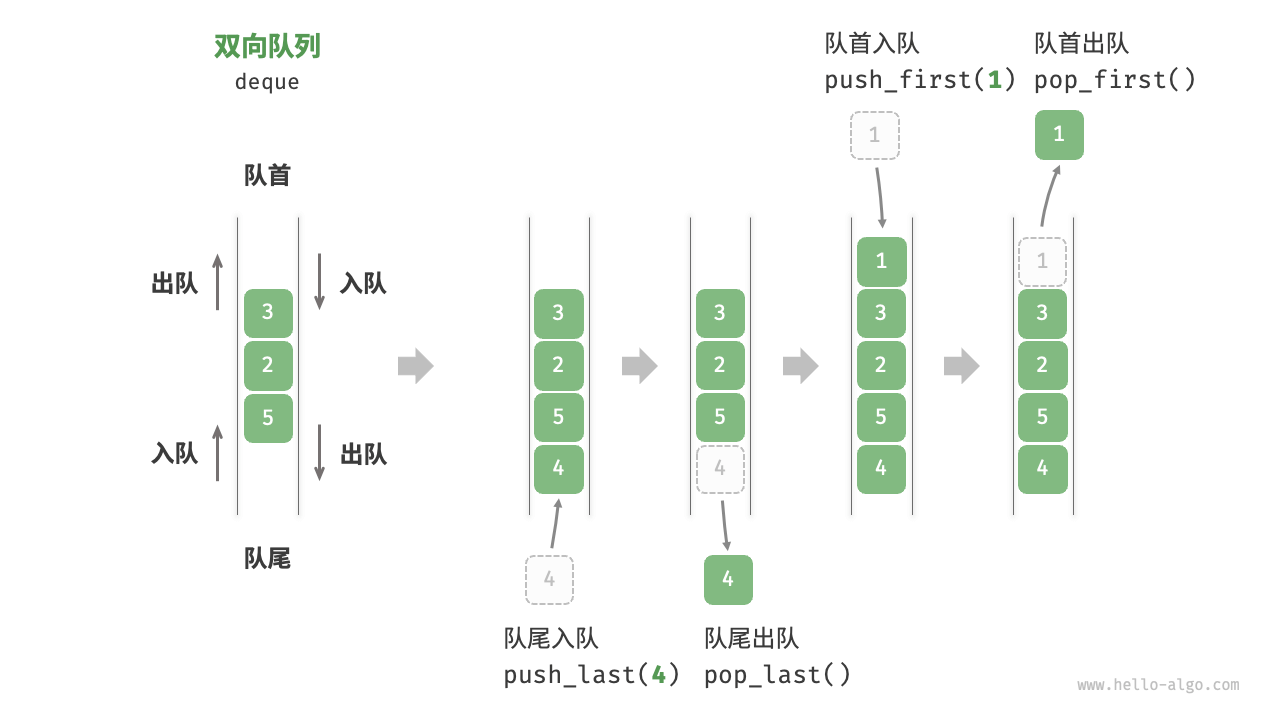

In [5]:
from collections import deque

# 初始化双向队列
deq: deque[int] = deque()
print(deq)

# 元素入队
deq.append(2)      # 添加至队尾
print(deq)
deq.append(5)
deq.append(4)
print(deq)
deq.appendleft(3)  # 添加至队首
print(deq)
deq.appendleft(1)
print(deq)

# 访问元素
front: int = deq[0]  # 队首元素
rear: int = deq[-1]  # 队尾元素
print(front, rear)
# 元素出队
pop_front: int = deq.popleft()  # 队首元素出队
pop_rear: int = deq.pop()       # 队尾元素出队
print(pop_front, pop_rear)

# 获取双向队列的长度
size: int = len(deq)
print(size)

# 判断双向队列是否为空
is_empty: bool = len(deq) == 0
print(is_empty)

deque([])
deque([2])
deque([2, 5, 4])
deque([3, 2, 5, 4])
deque([1, 3, 2, 5, 4])
1 4
1 4
3
False


## 双向队列实现 
双向队列的实现与队列类似，可以选择链表或数组作为底层数据结构。

对于双向队列而言，头部和尾部都可以执行入队和出队操作。换句话说，双向队列需要实现另一个对称方向的操作。

为此，我们采用“双向链表”作为双向队列的底层数据结构。

In [6]:
class ListNode:
    """双向链表节点"""

    def __init__(self, val: int):
        """构造方法"""
        self.val: int = val
        self.next: ListNode | None = None  # 后继节点引用
        self.prev: ListNode | None = None  # 前驱节点引用

class LinkedListDeque:
    """基于双向链表实现的双向队列"""

    def __init__(self):
        """构造方法"""
        self._front: ListNode | None = None  # 头节点 front
        self._rear: ListNode | None = None  # 尾节点 rear
        self._size: int = 0  # 双向队列的长度

    def size(self) -> int:
        """获取双向队列的长度"""
        return self._size

    def is_empty(self) -> bool:
        """判断双向队列是否为空"""
        return self._size == 0

    def push(self, num: int, is_front: bool):
        """入队操作"""
        node = ListNode(num)
        # 若链表为空，则令 front 和 rear 都指向 node
        if self.is_empty():
            self._front = self._rear = node
        # 队首入队操作
        elif is_front:
            # 将 node 添加至链表头部
            self._front.prev = node
            node.next = self._front
            self._front = node  # 更新头节点
        # 队尾入队操作
        else:
            # 将 node 添加至链表尾部
            self._rear.next = node
            node.prev = self._rear
            self._rear = node  # 更新尾节点
        self._size += 1  # 更新队列长度

    def push_first(self, num: int):
        """队首入队"""
        self.push(num, True)

    def push_last(self, num: int):
        """队尾入队"""
        self.push(num, False)

    def pop(self, is_front: bool) -> int:
        """出队操作"""
        if self.is_empty():
            raise IndexError("双向队列为空")
        # 队首出队操作
        if is_front:
            val: int = self._front.val  # 暂存头节点值
            # 删除头节点
            fnext: ListNode | None = self._front.next
            if fnext is not None:
                fnext.prev = None
                self._front.next = None
            self._front = fnext  # 更新头节点
        # 队尾出队操作
        else:
            val: int = self._rear.val  # 暂存尾节点值
            # 删除尾节点
            rprev: ListNode | None = self._rear.prev
            if rprev is not None:
                rprev.next = None
                self._rear.prev = None
            self._rear = rprev  # 更新尾节点
        self._size -= 1  # 更新队列长度
        return val

    def pop_first(self) -> int:
        """队首出队"""
        return self.pop(True)

    def pop_last(self) -> int:
        """队尾出队"""
        return self.pop(False)

    def peek_first(self) -> int:
        """访问队首元素"""
        if self.is_empty():
            raise IndexError("双向队列为空")
        return self._front.val

    def peek_last(self) -> int:
        """访问队尾元素"""
        if self.is_empty():
            raise IndexError("双向队列为空")
        return self._rear.val

    def to_array(self) -> list[int]:
        """返回数组用于打印"""
        node = self._front
        res = [0] * self.size()
        for i in range(self.size()):
            res[i] = node.val
            node = node.next
        return res

与基于数组实现队列类似，我们也可以使用环形数组来实现双向队列。

In [7]:
class ArrayDeque:
    """基于环形数组实现的双向队列"""

    def __init__(self, capacity: int):
        """构造方法"""
        self._nums: list[int] = [0] * capacity
        self._front: int = 0
        self._size: int = 0

    def capacity(self) -> int:
        """获取双向队列的容量"""
        return len(self._nums)

    def size(self) -> int:
        """获取双向队列的长度"""
        return self._size

    def is_empty(self) -> bool:
        """判断双向队列是否为空"""
        return self._size == 0

    def index(self, i: int) -> int:
        """计算环形数组索引"""
        # 通过取余操作实现数组首尾相连
        # 当 i 越过数组尾部后，回到头部
        # 当 i 越过数组头部后，回到尾部
        return (i + self.capacity()) % self.capacity()

    def push_first(self, num: int):
        """队首入队"""
        if self._size == self.capacity():
            print("双向队列已满")
            return
        # 队首指针向左移动一位
        # 通过取余操作实现 front 越过数组头部后回到尾部
        self._front = self.index(self._front - 1)
        # 将 num 添加至队首
        self._nums[self._front] = num
        self._size += 1

    def push_last(self, num: int):
        """队尾入队"""
        if self._size == self.capacity():
            print("双向队列已满")
            return
        # 计算队尾指针，指向队尾索引 + 1
        rear = self.index(self._front + self._size)
        # 将 num 添加至队尾
        self._nums[rear] = num
        self._size += 1

    def pop_first(self) -> int:
        """队首出队"""
        num = self.peek_first()
        # 队首指针向后移动一位
        self._front = self.index(self._front + 1)
        self._size -= 1
        return num

    def pop_last(self) -> int:
        """队尾出队"""
        num = self.peek_last()
        self._size -= 1
        return num

    def peek_first(self) -> int:
        """访问队首元素"""
        if self.is_empty():
            raise IndexError("双向队列为空")
        return self._nums[self._front]

    def peek_last(self) -> int:
        """访问队尾元素"""
        if self.is_empty():
            raise IndexError("双向队列为空")
        # 计算尾元素索引
        last = self.index(self._front + self._size - 1)
        return self._nums[last]

    def to_array(self) -> list[int]:
        """返回数组用于打印"""
        # 仅转换有效长度范围内的列表元素
        res = []
        for i in range(self._size):
            res.append(self._nums[self.index(self._front + i)])
        return res